In [18]:
from real_time_weather_ingestion import main_scrapper
from radar_image_processor import image_to_possible_storm
from datetime import datetime 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from PIL import Image

In [118]:
all_station_data = pd.read_csv('overall_station.csv')
all_station_data.head

<bound method NDFrame.head of                    Station Name  Latitude  Longitude Station ID
0           Ang Mo Kio Avenue 5   1.37640  103.84920       S109
1                Nanyang Avenue   1.34583  103.68166        S44
2                    Pulau Ubin   1.41680  103.96730       S106
3                   Banyan Road   1.25600  103.67900       S117
4                Kim Chuan Road   1.33990  103.88780        S43
5            East Coast Parkway   1.31350  103.96250       S107
6       Upper Changi Road North   1.36780  103.98260        S24
7           Tuas South Avenue 3   1.29377  103.61843       S115
8              Semakau Landfill   1.18900  103.76800       S102
9                   Scotts Road   1.31055  103.83650       S111
10                      Sentosa   1.25000  103.82790        S60
11            Yio Chu Kang Road   1.37999  103.87643       S219
12         Ang Mo Kio Avenue 10   1.36019  103.85335       S216
13             Bishan Street 13   1.35041  103.85526       S217
14        

In [ ]:
# shayne help me make sure ur weather station dataframe is named as all_station_data , then juz run this whole cell , at the end just upload all_station_data to the db will do 

########################################################################################
# do not change
lat_min, lat_max = 1.15, 1.47
lon_min, lon_max = 103.56, 104.14   
########################################################################################

########################################################################################
# do not change
scale_x = 217 / 853
scale_y = 120 / 479
########################################################################################


def latlon_to_xy(lat, lon, lat_min, lat_max, lon_min, lon_max, width, height):
    """
    Convert latitude and longitude to pixel coordinates on the radar image grid.

    Args:
        lat, lon : float
        lat_min, lat_max, lon_min, lon_max : float
            Bounding box of the radar coverage.
        width, height : int
            Dimensions of the radar image (e.g. 217x120).

    Returns:
        (x, y) pixel coordinates (integers)
    """

    # normalize longitude to horizontal position
    x = (lon - lon_min) / (lon_max - lon_min) * (width - 1)
    # normalize latitude to vertical position (note inversion: north is top)
    y = (lat_max - lat) / (lat_max - lat_min) * (height - 1)

    return int(round(x)), int(round(y))

def basemap_to_radar(X, Y):
    x = X * scale_x
    y = Y * scale_y
    return int(round(x)), int(round(y))

all_station_data['coord_basemap'] = all_station_data.apply(lambda row : latlon_to_xy(row['Latitude'],row['Longitude'],lat_min, lat_max, lon_min, lon_max,853,479),axis = 1)

all_station_data.rename(columns={'Station Name':'station_name','Latitude':'latitude','Longitude':'longitude','Station ID':'station_id'},inplace = True)


all_station_data["coord"] = all_station_data["coord_basemap"].apply(lambda xy: basemap_to_radar(xy[0], xy[1]))

,station_name,latitude,longitude,station_id,coord_basemap
0,Ang Mo Kio Avenue 5,1.37640,103.84920,S109,"(425, 140)"
1,Nanyang Avenue,1.34583,103.68166,S44,"(179, 185)"
2,Pulau Ubin,1.41680,103.96730,S106,"(598, 79)"


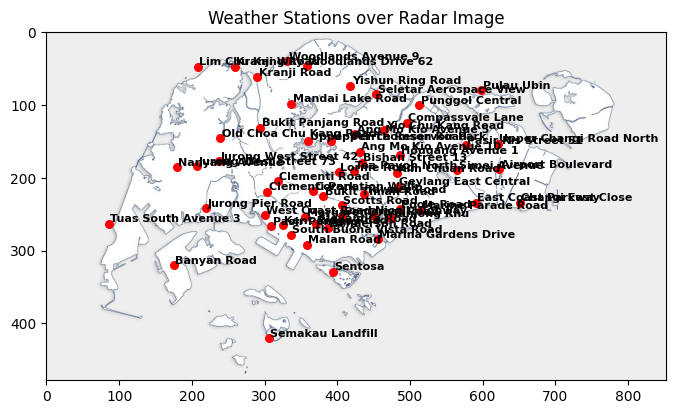

In [ ]:
xs, ys = zip(*all_station_data["coord_basemap"])

# Open radar image
img = Image.open("sample_data/base-853.png")

plt.figure(figsize=(8, 5))
plt.imshow(img)

# Plot weather stations
plt.scatter(xs, ys, color="red", s=30)

# Add station labels
for i, row in all_station_data.iterrows():
    x, y = row["coord_basemap"]      # unpack tuple
    plt.text(x + 2, y - 2, row["station_name"],
             color="black", fontsize=8, weight="bold")

plt.title("Weather Stations over Radar Image")
plt.show()

# H, W = img_or_grid.shape[:2]

# plt.figure(figsize=(8,5))
# # If it's a reflectivity grid/array:
# plt.imshow(img_or_grid, origin="upper")  # origin='upper' puts y=0 at top (radar-style)
# # If it's a Pillow/NumPy RGBA image, same call works.

# plt.scatter(stations_df["x"], stations_df["y"], s=35, c="red", label="Stations")

# # label each station
# for _, r in stations_df.iterrows():
#     plt.text(r["x"]+2, r["y"]-2, str(r["station_id"]),
#              fontsize=8, color="red", va="bottom", ha="left")

# # Do NOT also invert y if you used origin='upper'. Pick ONE of these:
# # plt.gca().invert_yaxis()        # <- use this only if you did NOT set origin='upper'

# plt.xlim(-2, W+2)
# plt.ylim(H+2, -2)  # equivalent to origin='upper' if you prefer this style
# plt.title("Weather Stations over Radar Image")
# plt.xlabel("X (pixel)"); plt.ylabel("Y (pixel)")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [146]:
scale_x = 217 / 853
scale_y = 120 / 479

def basemap_to_radar(X, Y):
    x = X * scale_x
    y = Y * scale_y
    return int(round(x)), int(round(y))

In [147]:
all_station_data["coord"] = all_station_data["coord_basemap"].apply(lambda xy: basemap_to_radar(xy[0], xy[1]))
all_station_data.head(2)

,station_name,latitude,longitude,station_id,coord_basemap,coord
0,Ang Mo Kio Avenue 5,1.37640,103.84920,S109,"(425, 140)","(108, 35)"
1,Nanyang Avenue,1.34583,103.68166,S44,"(179, 185)","(46, 46)"


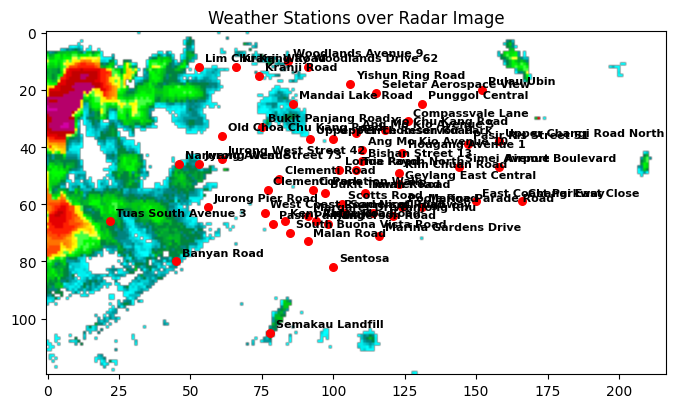

In [148]:
xs, ys = zip(*all_station_data["coord"])

# Open radar image
img = Image.open("sample_data/test_2.png")

plt.figure(figsize=(8, 5))
plt.imshow(img)

# Plot weather stations
plt.scatter(xs, ys, color="red", s=30)

# Add station labels
for i, row in all_station_data.iterrows():
    x, y = row["coord"]      # unpack tuple
    plt.text(x + 2, y - 2, row["station_name"],
             color="black", fontsize=8, weight="bold")

plt.title("Weather Stations over Radar Image")
plt.show()

In [15]:
# pull dummy data to work with
# ts_str = '202510091010'
current_datetime = datetime(2025,10,9,10,10,0)
run_datetime= current_datetime.replace(minute = 10,second = 0, microsecond=0).isoformat()

dummy_data = main_scrapper(run_datetime)
dummy_data

# humidity_df = humidity_api(run_datetime)
# temperature_df = temperature_api(run_datetime)
# wind_speed_df = wind_speed_api(run_datetime)
# wind_direction_df = wind_direction_api(run_datetime)
# rainfall_df = rainfall_api(run_datetime)


,time_stamp,station_id,wind_direction_degrees,wind_speed_knots,rainfall_mm,temperature_c,humidity_pct
0,2025-10-09T10:10:00,S109,273,13.5,0.2,23.4,90.2
1,2025-10-09T10:10:00,S106,273,5.0,0.0,26.7,80.8
2,2025-10-09T10:10:00,S117,290,4.7,0.0,24.1,90.8
3,2025-10-09T10:10:00,S107,251,13.7,0.0,26.4,75.5
4,2025-10-09T10:10:00,S115,274,5.5,0.4,24.5,97.4
5,2025-10-09T10:10:00,S60,277,8.7,0.0,23.9,85.2
6,2025-10-09T10:10:00,S44,359,6.5,0.4,22.6,99.1
7,2025-10-09T10:10:00,S43,274,7.6,1.8,23.7,91.6
8,2025-10-09T10:10:00,S111,225,12.0,3.4,21.3,98.6


In [16]:
dummy_data = dummy_data.merge(all_station_data, on = 'station_id' , how = 'left')
dummy_data

,time_stamp,station_id,wind_direction_degrees,wind_speed_knots,rainfall_mm,temperature_c,humidity_pct,station_name,latitude,longitude,coord
0,2025-10-09T10:10:00,S109,273,13.5,0.2,23.4,90.2,Ang Mo Kio Avenue 5,1.37640,103.84920,"(111, 56)"
1,2025-10-09T10:10:00,S106,273,5.0,0.0,26.7,80.8,Pulau Ubin,1.41680,103.96730,"(132, 52)"
2,2025-10-09T10:10:00,S117,290,4.7,0.0,24.1,90.8,Banyan Road,1.25600,103.67900,"(82, 67)"
3,2025-10-09T10:10:00,S107,251,13.7,0.0,26.4,75.5,East Coast Parkway,1.31350,103.96250,"(131, 62)"
4,2025-10-09T10:10:00,S115,274,5.5,0.4,24.5,97.4,Tuas South Avenue 3,1.29377,103.61843,"(72, 64)"
5,2025-10-09T10:10:00,S60,277,8.7,0.0,23.9,85.2,Sentosa,1.25000,103.82790,"(108, 68)"
6,2025-10-09T10:10:00,S44,359,6.5,0.4,22.6,99.1,Nanyang Avenue,1.34583,103.68166,"(83, 59)"
7,2025-10-09T10:10:00,S43,274,7.6,1.8,23.7,91.6,Kim Chuan Road,1.33990,103.88780,"(118, 60)"
8,2025-10-09T10:10:00,S111,225,12.0,3.4,21.3,98.6,Scotts Road,1.31055,103.83650,"(109, 62)"


In [28]:
with open('sample_data/test_image.jpg','rb') as f:
    data = f.read()

In [32]:
possible_storm_grid, possible_storm_df = image_to_possible_storm(data,50,80)

/Users/javier/VSCODE/local/DSA3101_vsc/dsa3101_final_project/DSA3101_storm_4/backend/storm_object_detector/radar_image_processor.py:47: RuntimeWarning: invalid value encountered in sqrt
  d  = np.sqrt(d2, dtype=np.float32)


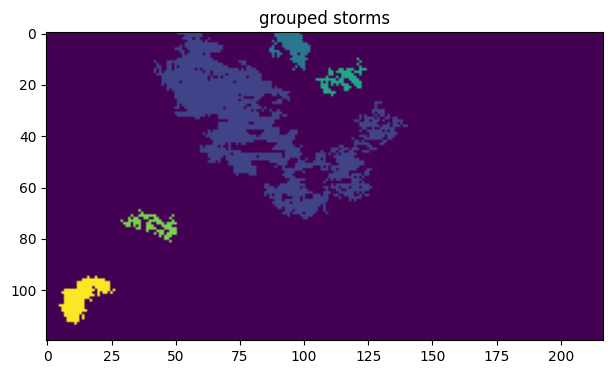

In [34]:
plt.figure(figsize=(8,4))           
plt.imshow(possible_storm_grid)      
plt.title("grouped storms")
plt.show()

In [35]:
possible_storm_df

,new_id,area_px,peak_dbz,anchor_y,anchor_x,centroid_y,centroid_x
0,1,2009,68.0,36.0,83.0,35.76,82.83
1,2,125,68.0,5.0,96.0,5.50,95.50
2,3,95,68.0,18.0,115.0,17.88,114.91
3,4,89,62.0,75.0,41.0,74.64,41.36
4,5,178,68.0,103.0,14.0,102.81,13.60


In [132]:
def storm_pixel_coordinates(
        storm_id
        ,full_storm_grid
): 
        # binary mask 
        storm_mask = (full_storm_grid == storm_id).astype(np.uint8)

        #print(int(storm_mask.sum()))

        # return coordinates for every pixel 
        ys,xs = np.where(storm_mask)

        # pack into dataframe 
        coord = list(zip(xs,ys))
        df = pd.DataFrame({'coord':coord})

        return df

def metric_threshold_calc(
        input_df
        ,wind_speed_threshold
        ,rainfall_threshold
        ,temperature_threshold
        ,humidty_threshold
): 
        res = False
        threshold_flags = [False,False,False,False]

        # if single station 
        if input_df.shape[0] == 1: 
                if input_df['wind_speed_knots'] >= wind_speed_threshold:
                        threshold_flags[0] = True
                if input_df['rainfall_mm'] >= rainfall_threshold:
                        threshold_flags[1] = True
                if input_df['temperature_c'] >= temperature_threshold:
                        threshold_flags[2] = True
                if input_df['humidity_pct'] >= humidty_threshold:
                        threshold_flags[3] = True


        # if multi station, average all 
        else:
                cols_to_avg = ["wind_speed_knots", "rainfall_mm", "temperature_c", "humidity_pct"]
                mean_df = input_df[cols_to_avg].mean()

                if mean_df['wind_speed_knots'] >= wind_speed_threshold:
                        threshold_flags[0] = True
                if mean_df['rainfall_mm'] >= rainfall_threshold:
                        threshold_flags[1] = True
                if mean_df['temperature_c'] <= temperature_threshold:
                        threshold_flags[2] = True
                if mean_df['humidity_pct'] >= humidty_threshold:
                        threshold_flags[3] = True

        if sum(threshold_flags) == 4:
                res = True
        return res


def x_y_distance(
        tuple
        ,x2
        ,y2
) : 
        if isinstance(tuple, float) and np.isnan(tuple):
                d = np.inf
        else:
                x1 = tuple[0]
                y1 = tuple[1]
                d = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

        return d

def storm_object_checker(
        storm_id
        ,possible_storm_grid

        ,weather_data_df

        # threshholds 
        ,wind_speed_threshold
        ,rainfall_threshold
        ,temperature_threshold
        ,humidty_threshold
): 
        curr_storm = storm_pixel_coordinates(storm_id, possible_storm_grid)

        nearby_stations = pd.merge(weather_data_df,curr_storm,how='inner' , on = 'coord')
        
        # storm does not encompass any stations
        if nearby_stations.shape[0] == 0:
                # find centriod point first
                xs, ys = zip(*curr_storm["coord"])
                anchor_y = round(float(ys.mean()),0)
                anchor_x = round(float(xs.mean()),0)
                weather_data_df['distance_to_station'] = weather_data_df['coord'].apply(lambda x: x_y_distance(x,anchor_x,anchor_y))
                weather_data_df.sort_values(by='distance_to_station',ascending=True,inplace=True,na_position='last')
                # call and return nearest station 
                nearby_stations = weather_data_df.head(1)

        res = metric_threshold_calc(nearby_stations,wind_speed_threshold,rainfall_threshold,temperature_threshold,humidty_threshold)
        
        return res


In [98]:
# take in grid and df, for each storm pull grid for that storm 
# then pull xy coord for every pixel in that storm 
# then check if it contains any of the station data 

test_storm= storm_pixel_coordinates(1,possible_storm_grid)
test_storm


contain_station = pd.merge(dummy_data,test_storm ,how = 'inner', on = 'coord')
contain_station

# metrics above threshold 
# pull first 




,time_stamp,station_id,wind_direction_degrees,wind_speed_knots,rainfall_mm,temperature_c,humidity_pct,coord
0,2025-10-09T10:10:00,S44,359,6.5,0.4,22.6,99.1,"(101, 71)"
1,2025-10-09T10:10:00,S111,225,12.0,3.4,21.3,98.6,"(102, 71)"


In [102]:
above = metric_threshold_calc(contain_station,5,1,25,90)
above


True

In [103]:
test= possible_storm_df['new_id'].unique().tolist()
test

[1, 2, 3, 4, 5]

In [104]:
test = possible_storm_df

In [106]:
test['output'] = test['new_id'].apply(lambda x: storm_object_checker(x,possible_storm_grid,dummy_data,5,1,25,90))
test

,new_id,area_px,peak_dbz,anchor_y,anchor_x,centroid_y,centroid_x,output
0,1,2009,68.0,36.0,83.0,35.76,82.83,True
1,2,125,68.0,5.0,96.0,5.50,95.50,False
2,3,95,68.0,18.0,115.0,17.88,114.91,False
3,4,89,62.0,75.0,41.0,74.64,41.36,False
4,5,178,68.0,103.0,14.0,102.81,13.60,False


In [109]:
test2 = dummy_data

In [110]:
test2

,time_stamp,station_id,wind_direction_degrees,wind_speed_knots,rainfall_mm,temperature_c,humidity_pct,coord
0,2025-10-09T10:10:00,S109,273,13.5,0.2,23.4,90.2,"(35, 95)"
1,2025-10-09T10:10:00,S106,273,5.0,0.0,26.7,80.8,NaN
2,2025-10-09T10:10:00,S117,290,4.7,0.0,24.1,90.8,NaN
3,2025-10-09T10:10:00,S107,251,13.7,0.0,26.4,75.5,"(175, 25)"
4,2025-10-09T10:10:00,S115,274,5.5,0.4,24.5,97.4,NaN
5,2025-10-09T10:10:00,S60,277,8.7,0.0,23.9,85.2,NaN
6,2025-10-09T10:10:00,S44,359,6.5,0.4,22.6,99.1,"(101, 71)"
7,2025-10-09T10:10:00,S43,274,7.6,1.8,23.7,91.6,NaN
8,2025-10-09T10:10:00,S111,225,12.0,3.4,21.3,98.6,"(102, 71)"


In [125]:
test2['distance_to_station'] = test2['coord'].apply(lambda x: x_y_distance(x,36,83))
test2

,time_stamp,station_id,wind_direction_degrees,wind_speed_knots,rainfall_mm,temperature_c,humidity_pct,coord,distance_to_station
0,2025-10-09T10:10:00,S109,273,13.5,0.2,23.4,90.2,"(35, 95)",12.041595
1,2025-10-09T10:10:00,S106,273,5.0,0.0,26.7,80.8,NaN,inf
2,2025-10-09T10:10:00,S117,290,4.7,0.0,24.1,90.8,NaN,inf
3,2025-10-09T10:10:00,S107,251,13.7,0.0,26.4,75.5,"(175, 25)",150.615404
4,2025-10-09T10:10:00,S115,274,5.5,0.4,24.5,97.4,NaN,inf
5,2025-10-09T10:10:00,S60,277,8.7,0.0,23.9,85.2,NaN,inf
6,2025-10-09T10:10:00,S44,359,6.5,0.4,22.6,99.1,"(101, 71)",66.098411
7,2025-10-09T10:10:00,S43,274,7.6,1.8,23.7,91.6,NaN,inf
8,2025-10-09T10:10:00,S111,225,12.0,3.4,21.3,98.6,"(102, 71)",67.082039


In [129]:
test2.sort_values(by='distance_to_station',ascending=True,inplace=True,na_position='last')
test2

,time_stamp,station_id,wind_direction_degrees,wind_speed_knots,rainfall_mm,temperature_c,humidity_pct,coord,distance_to_station
0,2025-10-09T10:10:00,S109,273,13.5,0.2,23.4,90.2,"(35, 95)",12.041595
6,2025-10-09T10:10:00,S44,359,6.5,0.4,22.6,99.1,"(101, 71)",66.098411
8,2025-10-09T10:10:00,S111,225,12.0,3.4,21.3,98.6,"(102, 71)",67.082039
3,2025-10-09T10:10:00,S107,251,13.7,0.0,26.4,75.5,"(175, 25)",150.615404
1,2025-10-09T10:10:00,S106,273,5.0,0.0,26.7,80.8,NaN,inf
2,2025-10-09T10:10:00,S117,290,4.7,0.0,24.1,90.8,NaN,inf
4,2025-10-09T10:10:00,S115,274,5.5,0.4,24.5,97.4,NaN,inf
5,2025-10-09T10:10:00,S60,277,8.7,0.0,23.9,85.2,NaN,inf
7,2025-10-09T10:10:00,S43,274,7.6,1.8,23.7,91.6,NaN,inf


In [130]:
test3 = test2.head(1)

In [131]:
print(type(test3))

<class 'pandas.core.frame.DataFrame'>
